# Saving directory

In [84]:
import os

# Définir le chemin de base et le répertoire à créer
saving_dir = "G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/receptive_field_overlaping"

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' la été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/receptive_field_overlaping' existe déjà.


# Verif data

In [22]:
import os

# Dossier de base
base_folder = r"G:\PhD\Experimentation\Calcium_imaging_WF\code_for_analysis\Ugo_script\z_score_processing\SUP_RF_overlap_quantif"

# Liste des dossiers dans le répertoire de base
folders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

# Affichage des noms des dossiers
print("Liste des dossiers dans le répertoire :")
for folder in folders:
    print(folder)


Liste des dossiers dans le répertoire :
overlap_2023.10.06
overlap_2023.10.07
overlap_2023.10.09_M1
overlap_2023.10.09_M2
overlap_2023.10.10
overlap_2023.10.11
overlap_2023.10.17
overlap_2023.10.18_M1
overlap_2023.10.18_M2
overlap_2023.11.08
overlap_2023.11.09
overlap_2023.11.10


# Creation des dataframe Cool & Hot

In [50]:
import pandas as pd
import os

def extract_data_from_file(file_path):
    """ Extrait les valeurs des colonnes thermo/tactile area, overlap/tactile et overlap/thermo à partir d'un fichier Excel. """
    try:
        df = pd.read_excel(file_path, header=None)
        thermo_tactile_area = df.iloc[1, 1]  # Valeur en B2
        overlap_tactile = df.iloc[2, 1]      # Valeur en B3
        overlap_thermo = df.iloc[3, 1]       # Valeur en B4
        return thermo_tactile_area, overlap_tactile, overlap_thermo
    except Exception as e:
        print(f"Erreur lors du traitement du fichier {file_path}: {e}")
        return None, None, None

def save_to_excel(all_data):
    """ Sauvegarde toutes les données dans un fichier Excel unique. """
    df = pd.DataFrame(all_data, columns=["animal", "rec", "thermo/tactile area", "overlap/tactile", "overlap/thermo"])
    output_file = "Thq_data_overlap.xlsx"
    df.to_excel(output_file, index=False)
    print(f"Les données ont été sauvegardées dans le fichier {output_file}")

# Dossier contenant les données
base_folder = r"G:\PhD\Experimentation\Calcium_imaging_WF\code_for_analysis\Ugo_script\z_score_processing\SUP_RF_overlap_quantif"

typenames = ["Thermic"]
all_data = []  # Liste pour stocker toutes les données

for typename in typenames:
    for animal_folder in os.listdir(base_folder):
        animal_path = os.path.join(base_folder, animal_folder)
        if os.path.isdir(animal_path):
            for file in os.listdir(animal_path):
                if file.startswith(typename) and file.endswith("_stats_tactile-mask.xlsx"):
                    file_path = os.path.join(animal_path, file)
                    
                    # Extraction des données
                    thermo_tactile_area, overlap_tactile, overlap_thermo = extract_data_from_file(file_path)
                    
                    # Extraire le nom de l'animal et du rec
                    animal_name = os.path.basename(animal_path).replace("overlap_", "")  # Extrait après "overlap_"
                    rec_name = file.split('_')[0] + "_" + file.split('_')[1]  # Exemple: "Thermic_2"
                    
                    # Vérification et ajout des données
                    if thermo_tactile_area is not None:
                        all_data.append([animal_name, rec_name, thermo_tactile_area, overlap_tactile, overlap_thermo])

# Sauvegarde uniquement si des données ont été extraites
if all_data:
    save_to_excel(all_data)
else:
    print("Aucune donnée extraite. Vérifiez vos fichiers et chemins.")


Les données ont été sauvegardées dans le fichier Thq_data_overlap.xlsx


In [46]:
import pandas as pd
import os

def extract_data_from_file(file_path):
    """ Extrait les valeurs des colonnes thermo/tactile area, overlap/tactile et overlap/thermo à partir d'un fichier Excel. """
    try:
        df = pd.read_excel(file_path, header=None)
        thermo_tactile_area = df.iloc[1, 1]  # Valeur en B2
        overlap_tactile = df.iloc[2, 1]      # Valeur en B3
        overlap_thermo = df.iloc[3, 1]       # Valeur en B4
        return thermo_tactile_area, overlap_tactile, overlap_thermo
    except Exception as e:
        print(f"Erreur lors du traitement du fichier {file_path}: {e}")
        return None, None, None

def save_to_excel(all_data):
    """ Sauvegarde toutes les données dans un fichier Excel unique. """
    df = pd.DataFrame(all_data, columns=["animal", "rec", "thermo/tactile area", "overlap/tactile", "overlap/thermo"])
    output_file = "hot_data_overlap.xlsx"
    df.to_excel(output_file, index=False)
    print(f"Les données ont été sauvegardées dans le fichier {output_file}")

# Dossier contenant les données
base_folder = r"G:\PhD\Experimentation\Calcium_imaging_WF\code_for_analysis\Ugo_script\z_score_processing\SUP_RF_overlap_quantif"

typenames = ["hot"]
all_data = []  # Liste pour stocker toutes les données

for typename in typenames:
    for animal_folder in os.listdir(base_folder):
        animal_path = os.path.join(base_folder, animal_folder)
        if os.path.isdir(animal_path):
            for file in os.listdir(animal_path):
                if file.startswith(typename) and file.endswith("_stats_tactile-mask.xlsx"):
                    file_path = os.path.join(animal_path, file)
                    
                    # Extraction des données
                    thermo_tactile_area, overlap_tactile, overlap_thermo = extract_data_from_file(file_path)
                    
                    # Extraire le nom de l'animal et du rec
                    animal_name = os.path.basename(animal_path).replace("overlap_", "")  # Extrait après "overlap_"
                    rec_name = file.split('_')[0] + "_" + file.split('_')[1]  # Exemple: "Thermic_2"
                    
                    # Vérification et ajout des données
                    if thermo_tactile_area is not None:
                        all_data.append([animal_name, rec_name, thermo_tactile_area, overlap_tactile, overlap_thermo])

# Sauvegarde uniquement si des données ont été extraites
if all_data:
    save_to_excel(all_data)
else:
    print("Aucune donnée extraite. Vérifiez vos fichiers et chemins.")


Les données ont été sauvegardées dans le fichier hot_data_overlap.xlsx


# Pie Chart

### Cool vs tactile

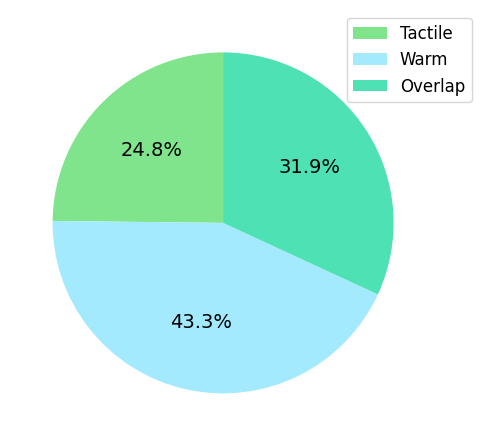

In [127]:
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

# Chemin du répertoire
base_path = r"G:\PhD\Experimentation\Calcium_imaging_WF\code_for_analysis\Ugo_script\z_score_processing\SUP_RF_overlap_quantif\\"

# Chargement des données depuis le fichier Excel
df = pd.read_excel(base_path + "Thq_data_overlap.xlsx")


# Initialisation des listes pour stocker les proportions
tactile_props = []
thermic_props = []
overlap_props = []

# Propriétés connues
thermo_tactile_area = sp.Rational(3.29)  # Conversion en Rational
overlap_tactile = sp.Rational(0.93)      # Proportion d'overlap de la zone tactile
overlap_thermo = sp.Rational(0.28)       # Proportion d'overlap de la zone thermique

# Définition des variables
tactile_area, thermic_area, overlap_area = sp.symbols('tactile_area thermic_area overlap_area')

# Équation pour l'aire combinée
eq1 = sp.Eq(tactile_area + thermic_area - overlap_area, thermo_tactile_area)

# Équation pour l'overlap
eq2 = sp.Eq(overlap_area, overlap_tactile * tactile_area)
eq3 = sp.Eq(overlap_area, overlap_thermo * thermic_area)

# Itération sur chaque ligne du DataFrame
for _, row in df.iterrows():
    # Extraction des valeurs pour chaque animal et enregistrement
    thermo_tactile_area_value = sp.Rational(row["thermo/tactile area"])
    overlap_tactile_value = sp.Rational(row["overlap/tactile"])
    overlap_thermo_value = sp.Rational(row["overlap/thermo"])

    # Résolution du système pour chaque animal-rec
    eq1 = sp.Eq(tactile_area + thermic_area - overlap_area, thermo_tactile_area_value)
    eq2 = sp.Eq(overlap_area, overlap_tactile_value * tactile_area)
    eq3 = sp.Eq(overlap_area, overlap_thermo_value * thermic_area)

    solution = sp.solve([eq1, eq2, eq3], (tactile_area, thermic_area, overlap_area))

    # Extraction des résultats
    tactile_area_value = solution[tactile_area]
    thermic_area_value = solution[thermic_area]
    overlap_area_value = solution[overlap_area]

    # Calcul des aires strictement tactile et thermique
    only_tactile_area = tactile_area_value - overlap_area_value
    only_thermic_area = thermic_area_value - overlap_area_value

    # Calcul des proportions
    tactile_prop = only_tactile_area / thermo_tactile_area_value
    thermic_prop = only_thermic_area / thermo_tactile_area_value
    overlap_prop = overlap_area_value / thermo_tactile_area_value

    # Ajout des proportions dans les listes
    tactile_props.append(tactile_prop.evalf())
    thermic_props.append(thermic_prop.evalf())
    overlap_props.append(overlap_prop.evalf())

# Calcul des moyennes des proportions
mean_tactile_prop = sum(tactile_props) / len(tactile_props)
mean_thermic_prop = sum(thermic_props) / len(thermic_props)
mean_overlap_prop = sum(overlap_props) / len(overlap_props)

# Création du pie chart avec les moyennes
labels = ['Tactile', 'Warm', 'Overlap']
sizes = [mean_tactile_prop, mean_thermic_prop, mean_overlap_prop]
colors = ['#80e48d', '#a3eaff', '#4de1b3']

plt.figure(figsize=(5, 5))
plt.pie(sizes, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 14})
plt.legend(labels, loc="upper left", fontsize=12, bbox_to_anchor=(0.77, 1))


plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'pie_cool_tac.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'pie_cool_tac.svg'), format='svg', dpi=300)


plt.show()


### Warm vs tactile

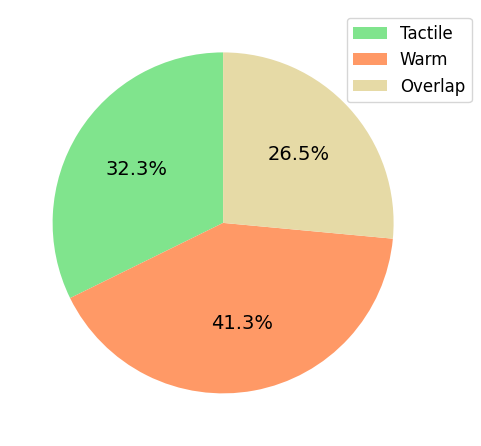

In [120]:
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

# Chemin du répertoire
base_path = r"G:\PhD\Experimentation\Calcium_imaging_WF\code_for_analysis\Ugo_script\z_score_processing\SUP_RF_overlap_quantif\\"

# Chargement des données depuis le fichier Excel
df = pd.read_excel(base_path + "hot_data_overlap.xlsx")


# Initialisation des listes pour stocker les proportions
tactile_props = []
thermic_props = []
overlap_props = []

# Propriétés connues
thermo_tactile_area = sp.Rational(3.29)  # Conversion en Rational
overlap_tactile = sp.Rational(0.93)      # Proportion d'overlap de la zone tactile
overlap_thermo = sp.Rational(0.28)       # Proportion d'overlap de la zone thermique

# Définition des variables
tactile_area, thermic_area, overlap_area = sp.symbols('tactile_area thermic_area overlap_area')

# Équation pour l'aire combinée
eq1 = sp.Eq(tactile_area + thermic_area - overlap_area, thermo_tactile_area)

# Équation pour l'overlap
eq2 = sp.Eq(overlap_area, overlap_tactile * tactile_area)
eq3 = sp.Eq(overlap_area, overlap_thermo * thermic_area)

# Itération sur chaque ligne du DataFrame
for _, row in df.iterrows():
    # Extraction des valeurs pour chaque animal et enregistrement
    thermo_tactile_area_value = sp.Rational(row["thermo/tactile area"])
    overlap_tactile_value = sp.Rational(row["overlap/tactile"])
    overlap_thermo_value = sp.Rational(row["overlap/thermo"])

    # Résolution du système pour chaque animal-rec
    eq1 = sp.Eq(tactile_area + thermic_area - overlap_area, thermo_tactile_area_value)
    eq2 = sp.Eq(overlap_area, overlap_tactile_value * tactile_area)
    eq3 = sp.Eq(overlap_area, overlap_thermo_value * thermic_area)

    solution = sp.solve([eq1, eq2, eq3], (tactile_area, thermic_area, overlap_area))

    # Extraction des résultats
    tactile_area_value = solution[tactile_area]
    thermic_area_value = solution[thermic_area]
    overlap_area_value = solution[overlap_area]

    # Calcul des aires strictement tactile et thermique
    only_tactile_area = tactile_area_value - overlap_area_value
    only_thermic_area = thermic_area_value - overlap_area_value

    # Calcul des proportions
    tactile_prop = only_tactile_area / thermo_tactile_area_value
    thermic_prop = only_thermic_area / thermo_tactile_area_value
    overlap_prop = overlap_area_value / thermo_tactile_area_value

    # Ajout des proportions dans les listes
    tactile_props.append(tactile_prop.evalf())
    thermic_props.append(thermic_prop.evalf())
    overlap_props.append(overlap_prop.evalf())

# Calcul des moyennes des proportions
mean_tactile_prop = sum(tactile_props) / len(tactile_props)
mean_thermic_prop = sum(thermic_props) / len(thermic_props)
mean_overlap_prop = sum(overlap_props) / len(overlap_props)

# Création du pie chart avec les moyennes
labels = ['Tactile', 'Warm', 'Overlap']
sizes = [mean_tactile_prop, mean_thermic_prop, mean_overlap_prop]
colors = ['#80e48d', '#ff9966', '#e6daa6']

plt.figure(figsize=(5, 5))
plt.pie(sizes, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 14})
plt.legend(labels, loc="upper left", fontsize=12, bbox_to_anchor=(0.77, 1))


plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'pie_hot_tac.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'pie_hot_tac.svg'), format='svg', dpi=300)


plt.show()
